Calibration size: (1936, 7468)
YH_2025_009_DEE_A.CSV: y=0.9775, MAE=0.177534
YH_2025_009_DEE_B.CSV: y=0.9717, MAE=0.171681
YH_2025_009_DEE_C.CSV: y=1.0182, MAE=0.218175
YH_2025_009_DMSO_A.CSV: y=0.8541, MAE=0.054102
YH_2025_009_DMSO_B.CSV: y=0.8963, MAE=0.096301
YH_2025_009_DMSO_C.CSV: y=0.9274, MAE=0.127399
YH_2025_009_IPA_A.CSV: y=0.6903, MAE=0.109686
YH_2025_009_IPA_B.CSV: y=0.8099, MAE=0.009948
YH_2025_009_IPA_C.CSV: y=0.9165, MAE=0.116534
YH_2025_009_Water_A.CSV: y=0.8786, MAE=0.078580
YH_2025_009_Water_B.CSV: y=0.8615, MAE=0.061548
YH_2025_009_Water_C.CSV: y=1.0168, MAE=0.216800

Average MAE: 0.119857


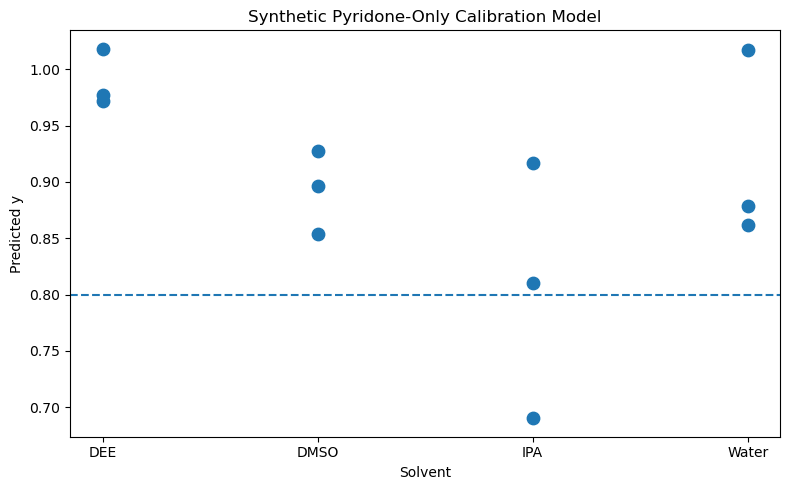

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

# ------------------ PATHS ------------------
pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

# ------------------ SETTINGS ------------------
n_components = 5
true_y = 0.8
alphas = np.arange(0.05, 0.25, 0.05)
fractions = np.linspace(0.4, 1.2, 121)  # synthetic pyridone fraction

rng = np.random.default_rng(42)

# ------------------ FUNCTIONS ------------------
def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def preprocess(spec, n_features):
    spec = spec[:n_features]
    return savgol_filter(spec, 15, 3, deriv=2)

def match_length(spec, target_len):
    return np.interp(np.linspace(0,1,target_len), np.linspace(0,1,len(spec)), spec)

def synthesize_spectrum(pyridone_spec, solvent_spec, alpha):
    return (1 - alpha) * pyridone_spec + alpha * solvent_spec

# ------------------ LOAD PURE PYRIDONE ------------------
pyridone_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_specs = [load_spectrum(os.path.join(pure_dir, f)) for f in pyridone_files]
n_features = min(len(s) for s in pure_specs)
pure_specs = [preprocess(s, n_features) for s in pure_specs]

# ------------------ LOAD SOLVENTS ------------------
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = match_length(s, n_features)
    s = preprocess(s, n_features)
    solvents.append(s)

# ------------------ SYNTHETIC CALIBRATION ------------------
X_cal, y_cal = [], []

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:
            pyridone = pure_specs[rng.integers(len(pure_specs))]
            synthetic = frac * pyridone
            synthetic = synthesize_spectrum(synthetic, solvent, alpha)
            synthetic += rng.normal(0, 0.005, size=synthetic.shape)  # small noise
            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
print(f"Calibration size: {X_cal.shape}")

# ------------------ SCALING ------------------
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

# ------------------ MODEL ------------------
pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# ------------------ TEST ------------------
test_files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith('.csv'))

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))
    s = match_length(s, n_features)
    s = preprocess(s, n_features)
    
    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])
    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)
    print(f"{file}: y={y_pred:.4f}, MAE={mae:.6f}")

print(f"\nAverage MAE: {np.mean(maes):.6f}")

# ------------------ PLOT ------------------
solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions, y_plot = [], []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_y, linestyle='--')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y')
plt.title('Synthetic Pyridone-Only Calibration Model')
plt.tight_layout()
plt.show()

Calibration size: (2904, 7468)
YH_2025_009_DEE_A.CSV: y=0.9956, MAE=0.1956
YH_2025_009_DEE_B.CSV: y=0.9950, MAE=0.1950
YH_2025_009_DEE_C.CSV: y=1.0382, MAE=0.2382
YH_2025_009_DMSO_A.CSV: y=0.8598, MAE=0.0598
YH_2025_009_DMSO_B.CSV: y=0.9006, MAE=0.1006
YH_2025_009_DMSO_C.CSV: y=0.9387, MAE=0.1387
YH_2025_009_IPA_A.CSV: y=0.6782, MAE=0.1218
YH_2025_009_IPA_B.CSV: y=0.8007, MAE=0.0007
YH_2025_009_IPA_C.CSV: y=0.9087, MAE=0.1087
YH_2025_009_Water_A.CSV: y=0.8871, MAE=0.0871
YH_2025_009_Water_B.CSV: y=0.8654, MAE=0.0654
YH_2025_009_Water_C.CSV: y=1.0392, MAE=0.2392

Average MAE: 0.1292


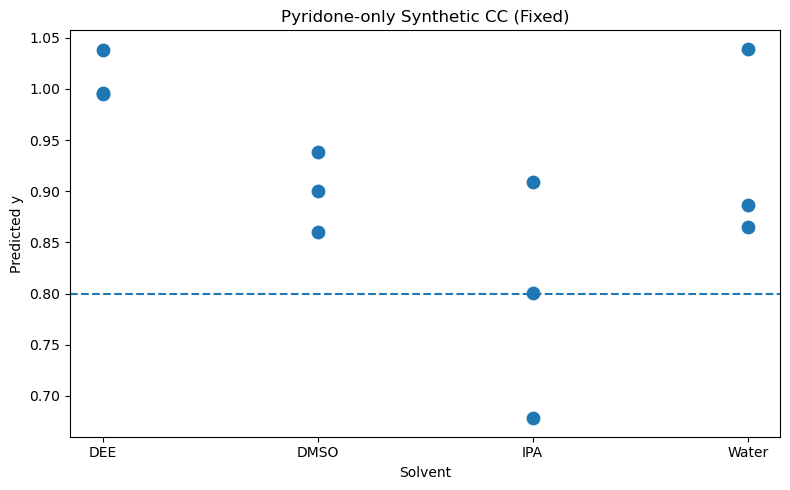

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

# ------------------ PATHS ------------------
pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

# ------------------ SETTINGS ------------------
fractions     = np.linspace(0.4, 1.2, 121)
alphas        = np.linspace(0.06, 0.28, 6)
n_components  = 5
true_y        = 0.8

rng = np.random.default_rng(42)

# ------------------ FUNCTIONS ------------------
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def preprocess(x, n_features):
    x = x[:n_features]
    x = savgol_filter(x, 15, 3, deriv=2)
    return x

def match_length(x, n_features):
    return np.interp(
        np.linspace(0,1,n_features),
        np.linspace(0,1,len(x)),
        x
    )

# ------------------ LOAD PURE CF3 ------------------
cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = [load_spectrum(os.path.join(pure_dir, f)) for f in cf3_files]
n_features = min(len(s) for s in pure_cf3)
pure_cf3 = [preprocess(s, n_features) for s in pure_cf3]

# ------------------ LOAD SOLVENTS ------------------
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = match_length(s, n_features)
    s = preprocess(s, n_features)
    solvents.append(s)

solvents = np.array(solvents)

# ------------------ SYNTHETIC CALIBRATION ------------------
X_cal, y_cal = [], []

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:

            cf3 = pure_cf3[rng.integers(len(pure_cf3))]

            # scale pyridone
            synthetic = frac * cf3

            # ✅ FIXED contamination (preserves variance)
            synthetic = (1 - alpha) * synthetic + alpha * solvent

            # small noise (helps generalization)
            synthetic += rng.normal(0, 0.003, size=synthetic.shape)

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Calibration size: {X_cal.shape}")

# ------------------ MODEL ------------------
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# ------------------ TEST ------------------
test_files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith('.csv'))

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))
    s = match_length(s, n_features)
    s = preprocess(s, n_features)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y={y_pred:.4f}, MAE={mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

# ------------------ PLOT ------------------
solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions = []
y_plot = []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_y, linestyle='--')

plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y')
plt.title('Pyridone-only Synthetic CC (Fixed)')
plt.tight_layout()
plt.show()

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

# ------------------ PATHS ------------------
pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

# ------------------ SETTINGS ------------------
fractions     = np.linspace(0.4, 1.2, 121)
alphas        = np.linspace(0.06, 0.28, 6)
n_components  = 5
true_y        = 0.8

rng = np.random.default_rng(42)

# ------------------ FUNCTIONS ------------------
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def preprocess(x, n_features):
    x = x[:n_features]
    x = savgol_filter(x, 15, 3, deriv=2)
    return x

# ------------------ LOAD PURE CF3 ------------------
cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = [load_spectrum(os.path.join(pure_dir, f)) for f in cf3_files]
n_features = min(len(s) for s in pure_cf3)
pure_cf3 = [preprocess(s, n_features) for s in pure_cf3]

# ------------------ LOAD SOLVENTS ------------------
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = np.interp(np.linspace(0,1,n_features), np.linspace(0,1,len(s)), s)
    s = preprocess(s, n_features)
    solvents.append(s)

solvents = np.array(solvents)

# ------------------ SYNTHETIC CALIBRATION ------------------
# ⚠️ NO delta trick anymore

X_cal, y_cal = [], []

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:

            cf3 = pure_cf3[rng.integers(len(pure_cf3))]

            # simple scaling (still imperfect physically, but not cheating)
            synthetic = frac * cf3

            # add solvent contamination
            synthetic = (synthetic + alpha * solvent) / (1 + alpha)

            # add noise (important!)
            synthetic += rng.normal(0, 0.005, size=synthetic.shape)

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Calibration size: {X_cal.shape}")

# ------------------ MODEL ------------------
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# ------------------ TEST (REAL DATA ONLY) ------------------
test_files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith('.csv'))

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))
    s = np.interp(np.linspace(0,1,n_features), np.linspace(0,1,len(s)), s)
    s = preprocess(s, n_features)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y={y_pred:.4f}, MAE={mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

Calibration size: (2904, 7468)
YH_2025_009_DEE_A.CSV: y=0.9942, MAE=0.1942
YH_2025_009_DEE_B.CSV: y=0.9875, MAE=0.1875
YH_2025_009_DEE_C.CSV: y=1.0324, MAE=0.2324
YH_2025_009_DMSO_A.CSV: y=0.8642, MAE=0.0642
YH_2025_009_DMSO_B.CSV: y=0.9078, MAE=0.1078
YH_2025_009_DMSO_C.CSV: y=0.9403, MAE=0.1403
YH_2025_009_IPA_A.CSV: y=0.6924, MAE=0.1076
YH_2025_009_IPA_B.CSV: y=0.8083, MAE=0.0083
YH_2025_009_IPA_C.CSV: y=0.9205, MAE=0.1205
YH_2025_009_Water_A.CSV: y=0.8842, MAE=0.0842
YH_2025_009_Water_B.CSV: y=0.8698, MAE=0.0698
YH_2025_009_Water_C.CSV: y=1.0283, MAE=0.2283

Average MAE: 0.1288


Loaded CF3 pure spectra (7468 features)
Loaded 4 solvent spectra
Synthetic calibration size: 2904
YH_2025_009_DEE_A.CSV: y = 0.8988, MAE = 0.0988
YH_2025_009_DEE_B.CSV: y = 0.9042, MAE = 0.1042
YH_2025_009_DEE_C.CSV: y = 0.9456, MAE = 0.1456
YH_2025_009_DMSO_A.CSV: y = 0.8543, MAE = 0.0543
YH_2025_009_DMSO_B.CSV: y = 0.8611, MAE = 0.0611
YH_2025_009_DMSO_C.CSV: y = 0.8361, MAE = 0.0361
YH_2025_009_IPA_A.CSV: y = 0.9098, MAE = 0.1098
YH_2025_009_IPA_B.CSV: y = 0.8638, MAE = 0.0638
YH_2025_009_IPA_C.CSV: y = 0.8989, MAE = 0.0989
YH_2025_009_Water_A.CSV: y = 0.8241, MAE = 0.0241
YH_2025_009_Water_B.CSV: y = 0.8231, MAE = 0.0231
YH_2025_009_Water_C.CSV: y = 0.9853, MAE = 0.1853

Average MAE: 0.0838


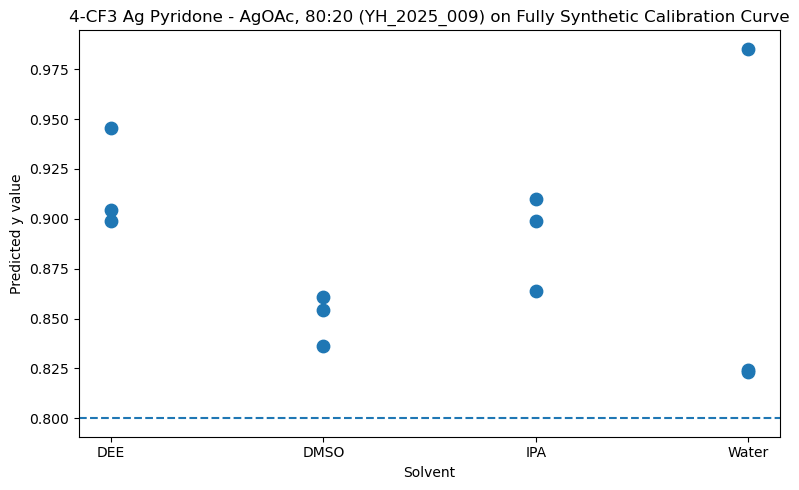


Results saved to YH_2025_009_AgOAc_solvent_anchored_pls.csv


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

fractions     = np.linspace(0.4, 1.2, 121)   
alphas        = np.linspace(0.06, 0.28, 6)   
n_components  = 5               
true_y        = 0.8               

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def average_replicates(files):
    specs = [load_spectrum(f) for f in files]
    min_len = min(len(s) for s in specs)
    specs = [s[:min_len] for s in specs]
    return np.mean(specs, axis=0)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)


cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]
pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )
    s = normalize(s)
    s = savgol(s)
    solvents.append(s)

solvents = np.array(solvents)
print(f"Loaded {len(solvents)} solvent spectra")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:
            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)
            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Fully Synthetic Calibration Curve')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})

Loaded pyridone spectrum  (7468 features)
Loaded AgOAc spectrum     (7468 features)

Calibration set: 11 spectra
  pyridone fractions: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
  Calibration MAE: 0.0000
YH_2025_009_DEE_A.CSV: y_pyridone = 1.6308,  MAE = 0.8308
YH_2025_009_DEE_B.CSV: y_pyridone = 1.3932,  MAE = 0.5932
YH_2025_009_DEE_C.CSV: y_pyridone = 0.3223,  MAE = 0.4777
YH_2025_009_DMSO_A.CSV: y_pyridone = 1.3759,  MAE = 0.5759
YH_2025_009_DMSO_B.CSV: y_pyridone = 0.2404,  MAE = 0.5596
YH_2025_009_DMSO_C.CSV: y_pyridone = 0.8437,  MAE = 0.0437
YH_2025_009_IPA_A.CSV: y_pyridone = 0.8699,  MAE = 0.0699
YH_2025_009_IPA_B.CSV: y_pyridone = 1.6637,  MAE = 0.8637
YH_2025_009_IPA_C.CSV: y_pyridone = 1.8835,  MAE = 1.0835
YH_2025_009_Water_A.CSV: y_pyridone = 0.9599,  MAE = 0.1599
YH_2025_009_Water_B.CSV: y_pyridone = 1.0818,  MAE = 0.2818
YH_2025_009_Water_C.CSV: y_pyridone = 0.9238,  MAE = 0.1238

Average MAE across test files: 0.4720


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 4
  warnings.warn(f"y residual is constant at iteration {k}")


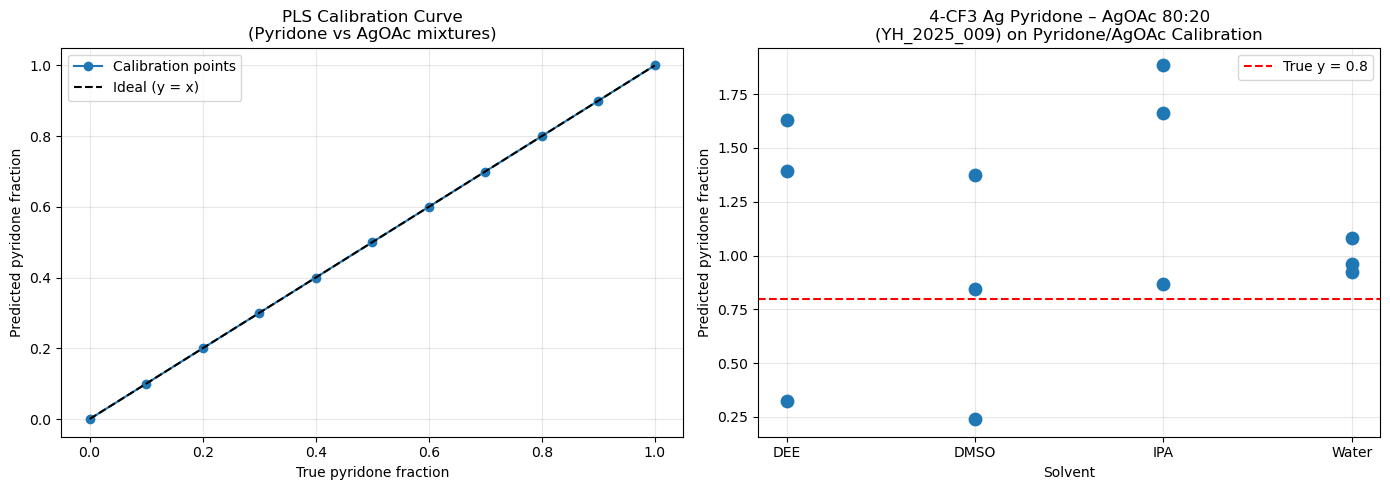


               Test_File  Predicted_y      MAE
  YH_2025_009_DEE_A.CSV     1.630790 0.830790
  YH_2025_009_DEE_B.CSV     1.393205 0.593205
  YH_2025_009_DEE_C.CSV     0.322297 0.477703
 YH_2025_009_DMSO_A.CSV     1.375859 0.575859
 YH_2025_009_DMSO_B.CSV     0.240379 0.559621
 YH_2025_009_DMSO_C.CSV     0.843692 0.043692
  YH_2025_009_IPA_A.CSV     0.869879 0.069879
  YH_2025_009_IPA_B.CSV     1.663747 0.863747
  YH_2025_009_IPA_C.CSV     1.883502 1.083502
YH_2025_009_Water_A.CSV     0.959906 0.159906
YH_2025_009_Water_B.CSV     1.081820 0.281820
YH_2025_009_Water_C.CSV     0.923837 0.123837


In [1]:
#Version 0.7
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

n_components  = 5
true_y        = 0.8   # pyridone fraction in test samples

# ── helpers ──────────────────────────────────────────────────────────────────
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

def average_replicates(dir_path, filenames, n_features=None):
    specs = [load_spectrum(os.path.join(dir_path, f)) for f in filenames]
    if n_features is not None:
        specs = [s[:n_features] if len(s) >= n_features
                 else np.interp(np.linspace(0, 1, n_features),
                                np.linspace(0, 1, len(s)), s)
                 for s in specs]
    min_len = min(len(s) for s in specs)
    return np.mean([s[:min_len] for s in specs], axis=0)

# ── load & preprocess pure component spectra ─────────────────────────────────
pyridone_files = ['YH_2025_010_4CF3_A.CSV',  'YH_2025_010_4CF3_B.CSV',  'YH_2025_010_4CF3_C.CSV']
ag_files       = ['YH_2025_010_AgOAC_A.CSV', 'YH_2025_010_AgOAC_B.CSV', 'YH_2025_010_AgOAC_C.CSV']

# Determine feature length from first pyridone file
n_features = len(load_spectrum(os.path.join(pure_dir, pyridone_files[0])))

pure_pyridone = average_replicates(pure_dir, pyridone_files, n_features)
pure_ag       = average_replicates(pure_dir, ag_files,       n_features)

# Normalize then apply Savitzky-Golay
pure_pyridone = savgol(normalize(pure_pyridone))
pure_ag       = savgol(normalize(pure_ag))

print(f"Loaded pyridone spectrum  ({n_features} features)")
print(f"Loaded AgOAc spectrum     ({n_features} features)")

# ── build calibration curve: linear mixtures 0:1 → 1:0 ──────────────────────
# y = pyridone fraction  (0.0, 0.1, 0.2, … 1.0)
pyridone_fractions = np.round(np.linspace(0, 1, 11), 1)   # 11 points

X_cal, y_cal = [], []
for frac in pyridone_fractions:
    mixed = frac * pure_pyridone + (1 - frac) * pure_ag
    X_cal.append(mixed)
    y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"\nCalibration set: {len(X_cal)} spectra")
print("  pyridone fractions:", pyridone_fractions)

# ── fit PLS ──────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# Quick sanity-check on calibration set itself
y_cal_pred = pls.predict(X_cal_scaled).ravel()
print(f"  Calibration MAE: {mean_absolute_error(y_cal, y_cal_pred):.4f}")

# ── predict test samples ──────────────────────────────────────────────────────
test_files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith('.csv'))

predictions, maes = [], []
for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = savgol(normalize(s))
    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])
    mae    = mean_absolute_error([true_y], [y_pred])
    predictions.append((file, y_pred))
    maes.append(mae)
    print(f"{file}: y_pyridone = {y_pred:.4f},  MAE = {mae:.4f}")

print(f"\nAverage MAE across test files: {np.mean(maes):.4f}")

# ── plot calibration curve ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: calibration fit
axes[0].plot(y_cal, y_cal_pred, 'o-', label='Calibration points')
axes[0].plot([0, 1], [0, 1], 'k--', label='Ideal (y = x)')
axes[0].set_xlabel('True pyridone fraction')
axes[0].set_ylabel('Predicted pyridone fraction')
axes[0].set_title('PLS Calibration Curve\n(Pyridone vs AgOAc mixtures)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: test predictions per solvent
solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_pos = np.repeat(np.arange(len(solvent_labels)), 3)
y_vals = [p[1] for p in predictions]

axes[1].scatter(x_pos, y_vals, s=80, zorder=3)
axes[1].axhline(true_y, linestyle='--', color='red', label=f'True y = {true_y}')
axes[1].set_xticks(range(len(solvent_labels)))
axes[1].set_xticklabels(solvent_labels)
axes[1].set_xlabel('Solvent')
axes[1].set_ylabel('Predicted pyridone fraction')
axes[1].set_title('4-CF3 Ag Pyridone – AgOAc 80:20\n(YH_2025_009) on Pyridone/AgOAc Calibration')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── results dataframe ─────────────────────────────────────────────────────────
df = pd.DataFrame({
    'Test_File':   [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE':          maes
})
print("\n", df.to_string(index=False))

Synthetic calibration set size: (1936, 7468)
YH_2025_009_DEE_A.CSV: predicted y=0.8027, MAE=0.002705
YH_2025_009_DEE_B.CSV: predicted y=0.8027, MAE=0.002705
YH_2025_009_DEE_C.CSV: predicted y=0.8032, MAE=0.003162
YH_2025_009_DMSO_A.CSV: predicted y=0.8025, MAE=0.002518
YH_2025_009_DMSO_B.CSV: predicted y=0.8031, MAE=0.003149
YH_2025_009_DMSO_C.CSV: predicted y=0.8031, MAE=0.003149
YH_2025_009_IPA_A.CSV: predicted y=0.7998, MAE=0.000181
YH_2025_009_IPA_B.CSV: predicted y=0.8005, MAE=0.000521
YH_2025_009_IPA_C.CSV: predicted y=0.8024, MAE=0.002416
YH_2025_009_Water_A.CSV: predicted y=0.8003, MAE=0.000276
YH_2025_009_Water_B.CSV: predicted y=0.8029, MAE=0.002874
YH_2025_009_Water_C.CSV: predicted y=0.8017, MAE=0.001715

Average MAE: 0.002114


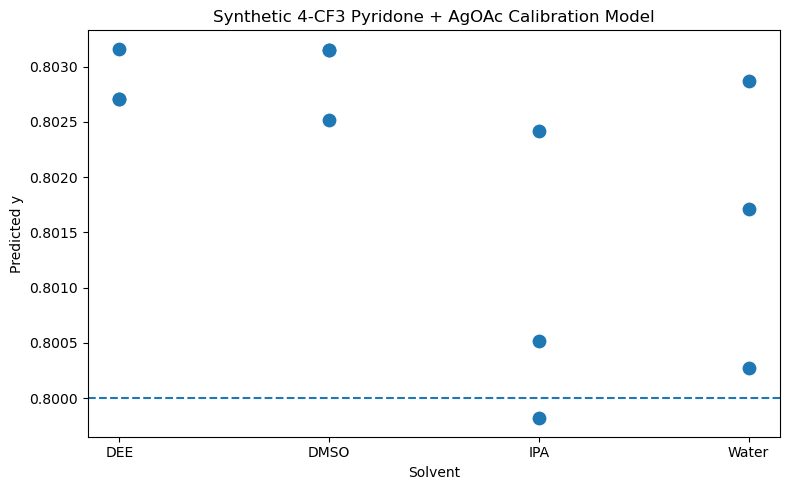

In [14]:
#Verision 0.8
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

# ------------------ PATHS ------------------
pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # 4-CF3 + AgOAc
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

# ------------------ SETTINGS ------------------
n_components = 5
alphas = np.arange(0.05, 0.25, 0.05)  # solvent contamination
fractions = np.linspace(0.4, 1.2, 121)  # fraction of pyridone in synthetic mixture
true_fraction_pyridone = 0.8
true_fraction_ag = 0.2

rng = np.random.default_rng(42)

# ------------------ FUNCTIONS ------------------
def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def preprocess(spec, n_features):
    spec = spec[:n_features]
    return savgol_filter(spec, 15, 3, deriv=2)

def match_length(spec, target_len):
    return np.interp(np.linspace(0,1,target_len), np.linspace(0,1,len(spec)), spec)

def synthesize_mixture(pyridone_spec, ag_spec, fraction_pyridone):
    return fraction_pyridone * pyridone_spec + (1 - fraction_pyridone) * ag_spec

def add_solvent_contamination(spec, solvent_spec, alpha):
    return (spec + alpha * solvent_spec) / (1 + alpha)

# ------------------ LOAD PURE COMPONENTS ------------------
pyridone_files = ['YH_2025_010_4CF3_A.CSV','YH_2025_010_4CF3_B.CSV','YH_2025_010_4CF3_C.CSV']
ag_files = ['YH_2025_010_AgOAC_A.CSV','YH_2025_010_AgOAC_B.CSV','YH_2025_010_AgOAC_C.CSV']

pyridone_specs = [load_spectrum(os.path.join(pure_dir,f)) for f in pyridone_files]
ag_specs = [load_spectrum(os.path.join(pure_dir,f)) for f in ag_files]

n_features = min(min(len(s) for s in pyridone_specs), min(len(s) for s in ag_specs))
pyridone_specs = [preprocess(s[:n_features], n_features) for s in pyridone_specs]
ag_specs = [preprocess(s[:n_features], n_features) for s in ag_specs]

# ------------------ LOAD SOLVENTS ------------------
solvent_files = ['YH_2025_007_DEE.csv','YH_2025_007_DMSO.csv','YH_2025_007_IPA.csv','YH_2025_007_Water.csv']
solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = match_length(s, n_features)
    s = preprocess(s, n_features)
    solvents.append(s)

# ------------------ SYNTHETIC CALIBRATION ------------------
X_cal, y_cal = [], []

for solvent in solvents:
    for frac in fractions:
        for alpha_val in alphas:
            pyridone = pyridone_specs[rng.integers(len(pyridone_specs))]
            ag = ag_specs[rng.integers(len(ag_specs))]

            mixture = synthesize_mixture(pyridone, ag, frac)
            mixture = add_solvent_contamination(mixture, solvent, alpha_val)
            mixture += rng.normal(0, 0.003, size=mixture.shape)  # small noise

            X_cal.append(mixture)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
print(f"Synthetic calibration set size: {X_cal.shape}")

# ------------------ SCALE & MODEL ------------------
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# ------------------ TEST ------------------
test_files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith('.csv'))

predictions, maes = [], []

for file in test_files:
    pyridone = pyridone_specs[rng.integers(len(pyridone_specs))]
    ag = ag_specs[rng.integers(len(ag_specs))]
    
    mixture = synthesize_mixture(pyridone, ag, true_fraction_pyridone)

    # choose solvent based on file name
    for i, sol_name in enumerate(['DEE','DMSO','IPA','Water']):
        if sol_name in file:
            mixture = add_solvent_contamination(mixture, solvents[i], alphas[0])
            break

    mixture_scaled = scaler.transform(mixture.reshape(1,-1))
    y_pred = float(pls.predict(mixture_scaled)[0])
    mae = mean_absolute_error([true_fraction_pyridone], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)
    print(f"{file}: predicted y={y_pred:.4f}, MAE={mae:.6f}")

print(f"\nAverage MAE: {np.mean(maes):.6f}")

# ------------------ PLOT ------------------
solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions, y_plot = [], []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_fraction_pyridone, linestyle='--')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y')
plt.title('Synthetic 4-CF3 Pyridone + AgOAc Calibration Model')
plt.tight_layout()
plt.show()

[0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919 0.2020202  0.21212121 0.22222222 0.23232323
 0.24242424 0.25252525 0.26262626 0.27272727 0.28282828 0.29292929
 0.3030303  0.31313131 0.32323232 0.33333333 0.34343434 0.35353535
 0.36363636 0.37373737 0.38383838 0.39393939 0.4040404  0.41414141
 0.42424242 0.43434343 0.44444444 0.45454545 0.46464646 0.47474747
 0.48484848 0.49494949 0.50505051 0.51515152 0.52525253 0.53535354
 0.54545455 0.55555556 0.56565657 0.57575758 0.58585859 0.5959596
 0.60606061 0.61616162 0.62626263 0.63636364 0.64646465 0.65656566
 0.66666667 0.67676768 0.68686869 0.6969697  0.70707071 0.71717172
 0.72727273 0.73737374 0.74747475 0.75757576 0.76767677 0.77777778
 0.78787879 0.7979798  0.80808081 0.81818182 0.82828283 0.83838384
 0.84848485 0.85858586 0.86868687 0.87878788 0.88888889 0.89898

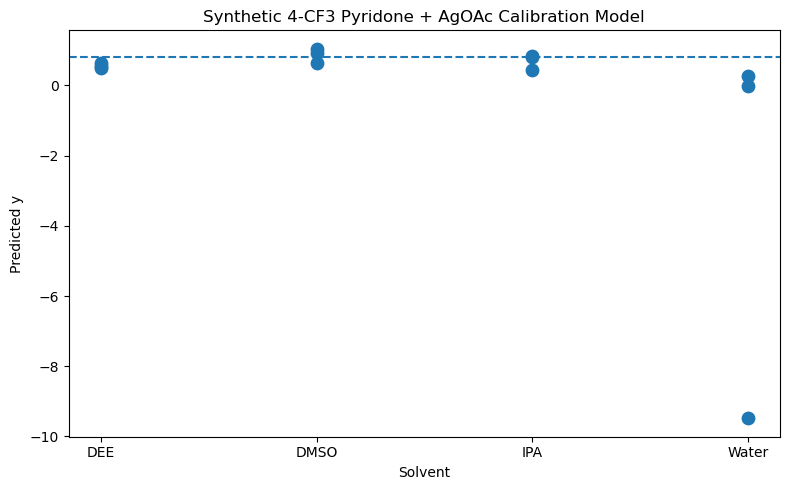

In [2]:
#Verision 0.9
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

# ------------------ PATHS ------------------
pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # 4-CF3 + AgOAc
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

# ------------------ SETTINGS ------------------
n_components = 5
alphas = np.arange(0.05, 0.25, 0.05)  # solvent contamination
fractions = np.linspace(0, 1, 100)  # fraction of pyridone in synthetic mixture
print(fractions)
true_fraction_pyridone = 0.8
true_fraction_ag = 0.2

rng = np.random.default_rng(42)

# ------------------ FUNCTIONS ------------------
def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def preprocess(spec, n_features):
    spec = spec[:n_features]
    return savgol_filter(spec, 15, 3, deriv=2)

def match_length(spec, target_len):
    return np.interp(np.linspace(0,1,target_len), np.linspace(0,1,len(spec)), spec)

def synthesize_mixture(pyridone_spec, ag_spec, fraction_pyridone):
    return fraction_pyridone * pyridone_spec + (1 - fraction_pyridone) * ag_spec

def add_solvent_contamination(spec, solvent_spec, alpha):
    return (spec + alpha * solvent_spec) / (1 + alpha)

# ------------------ LOAD PURE COMPONENTS ------------------
pyridone_files = ['YH_2025_010_4CF3_A.CSV','YH_2025_010_4CF3_B.CSV','YH_2025_010_4CF3_C.CSV']
ag_files = ['YH_2025_010_AgOAC_A.CSV','YH_2025_010_AgOAC_B.CSV','YH_2025_010_AgOAC_C.CSV']

pyridone_specs = [load_spectrum(os.path.join(pure_dir,f)) for f in pyridone_files]
ag_specs = [load_spectrum(os.path.join(pure_dir,f)) for f in ag_files]

n_features = min(min(len(s) for s in pyridone_specs), min(len(s) for s in ag_specs))
#pyridone_specs = [preprocess(s[:n_features], n_features) for s in pyridone_specs]
#ag_specs = [preprocess(s[:n_features], n_features) for s in ag_specs]

# ------------------ LOAD SOLVENTS ------------------
solvent_files = ['YH_2025_007_DEE.csv','YH_2025_007_DMSO.csv','YH_2025_007_IPA.csv','YH_2025_007_Water.csv']
solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    print(s)
    s = match_length(s, n_features)
    s = preprocess(s, n_features)
    solvents.append(s)

# ------------------ SYNTHETIC CALIBRATION ------------------
X_cal, y_cal = [], []

for solvent_idx, solvent in enumerate(solvents):
    for frac in fractions:
        for alpha_val in alphas:
            pyridone = pyridone_specs[rng.integers(len(pyridone_specs))]
            ag = ag_specs[rng.integers(len(ag_specs))]

            mixture = synthesize_mixture(pyridone, ag, frac)
            mixture = add_solvent_contamination(mixture, solvent, alpha_val)
            mixture += rng.normal(0, 0.003, size=mixture.shape)

            X_cal.append(mixture)
            y_cal.append(frac)

            # ✅ Print ALL spectra
            print(f"\nSpectrum {len(X_cal)} | frac={frac:.2f} | alpha={alpha_val:.2f} | solvent={solvent_labels[solvent_idx]}")
            print(mixture)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
print(f"\nSynthetic calibration set size: {X_cal.shape}")

# ------------------ SCALE & MODEL ------------------
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# ------------------ TEST ------------------
test_files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith('.csv'))
3
predictions, maes = [], []

for file in test_files:
    testspectrum = load_spectrum(os.path.join(test_dir, file)).reshape(1, -1)
    #testspectrum = preprocess(testspectrum, n_features)
    testspectrum = scaler.transform(testspectrum)
    y_pred = float(pls.predict(testspectrum)[0])
    mae = mean_absolute_error([true_fraction_pyridone], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)
    print(f"{file}: predicted y={y_pred:.4f}, MAE={mae:.6f}")

print(f"\nAverage MAE: {np.mean(maes):.6f}")

# ------------------ PLOT ------------------
solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions, y_plot = [], []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

import matplotlib.pyplot as plt

wavenumbers = np.linspace(400, 1800, n_features)

colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan']
    
plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_fraction_pyridone, linestyle='--')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y')
plt.title('Synthetic 4-CF3 Pyridone + AgOAc Calibration Model')
plt.tight_layout()
plt.show()

Synthetic calibration set size: 1936 × 7468 features
File	Predicted y	True y	MAE
YH_2025_003-10A.CSV	0.6894	0.1000	0.5894
YH_2025_003-10B.CSV	0.6940	0.1000	0.5940
YH_2025_003-10C.CSV	0.7284	0.1000	0.6284
YH_2025_003-11A.CSV	0.2856	0.0000	0.2856
YH_2025_003-11B.CSV	0.4036	0.0000	0.4036
YH_2025_003-11C.CSV	0.2187	0.0000	0.2187
YH_2025_003-1A.CSV	1.1096	1.0000	0.1096
YH_2025_003-1B.CSV	1.1121	1.0000	0.1121
YH_2025_003-1C.CSV	1.0782	1.0000	0.0782
YH_2025_003-2A.CSV	1.0741	0.9000	0.1741
YH_2025_003-2B.CSV	1.0611	0.9000	0.1611
YH_2025_003-2C.CSV	1.1168	0.9000	0.2168
YH_2025_003-3A.CSV	0.9942	0.8000	0.1942
YH_2025_003-3B.CSV	0.9175	0.8000	0.1175
YH_2025_003-3C.CSV	0.9267	0.8000	0.1267
YH_2025_003-4A.CSV	0.9109	0.7000	0.2109
YH_2025_003-4B.CSV	0.9546	0.7000	0.2546
YH_2025_003-4C.CSV	1.0604	0.7000	0.3604
YH_2025_003-5A.CSV	0.9889	0.6000	0.3889
YH_2025_003-5B.CSV	1.0661	0.6000	0.4661
YH_2025_003-5C.CSV	1.0078	0.6000	0.4078
YH_2025_003-6A.CSV	0.9505	0.5000	0.4505
YH_2025_003-6B.CSV	0.8698	0.5000	

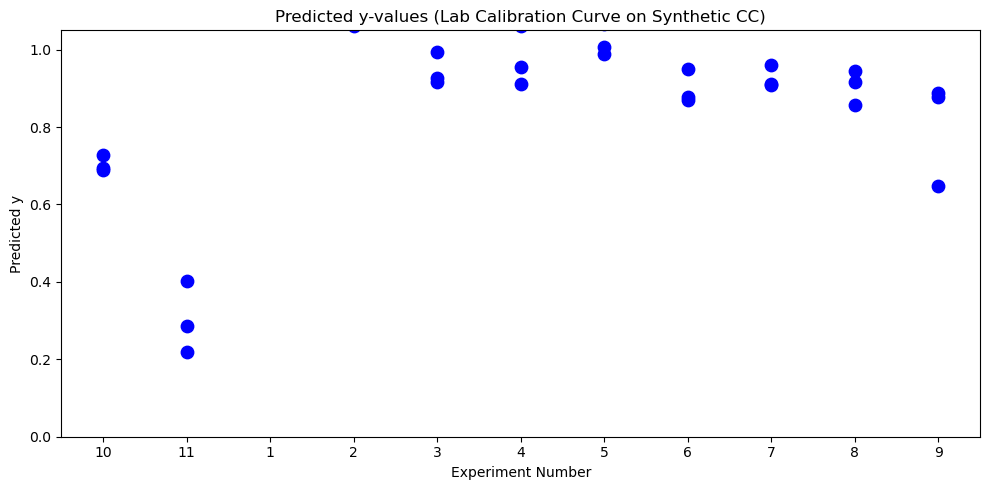

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

# ------------------ PATHS ------------------
pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # 4-CF3 + AgOAc
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
lab_calib_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'  # lab spectra (33 points)

# ------------------ SETTINGS ------------------
fractions = np.linspace(0.0, 1.2, 121)
alphas = np.arange(0.05, 0.25, 0.05)
n_components = 5

# True lab y-values
y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
            0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
            0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

# x-axis experiment order: 10, 11, 1, 2, ..., 9
experiment_order = [10, 11, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# ------------------ FUNCTIONS ------------------
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol_filter_spec(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

def synthesize_spectrum(alpha_spec, ag_spec, fraction_alpha):
    return fraction_alpha * alpha_spec + (1 - fraction_alpha) * ag_spec

def add_solvent_contamination(spec, solvent, alpha_val):
    return (spec + alpha_val * solvent) / (1 + alpha_val)

# ------------------ LOAD PURE COMPONENTS ------------------
alpha_files = ['YH_2025_010_4CF3_A.CSV', 'YH_2025_010_4CF3_B.CSV', 'YH_2025_010_4CF3_C.CSV']
ag_files    = ['YH_2025_010_AgOAC_A.CSV', 'YH_2025_010_AgOAC_B.CSV', 'YH_2025_010_AgOAC_C.CSV']

alpha_specs = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in alpha_files]
ag_specs    = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in ag_files]

# ------------------ LOAD SOLVENTS ------------------
solvent_files = ['YH_2025_007_DEE.csv', 'YH_2025_007_DMSO.csv', 'YH_2025_007_IPA.csv', 'YH_2025_007_Water.csv']
solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = np.interp(np.linspace(0, 1, len(alpha_specs[0])), np.linspace(0, 1, len(s)), s)
    s = normalize(savgol_filter_spec(s))
    solvents.append(s)

# ------------------ SYNTHETIC CALIBRATION ------------------
X_cal, y_cal = [], []
rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha_val in alphas:
            alpha_spec = alpha_specs[rng.integers(len(alpha_specs))]
            ag_spec    = ag_specs[rng.integers(len(ag_specs))]
            mix_spec = synthesize_spectrum(alpha_spec, ag_spec, frac)
            synthetic_spec = add_solvent_contamination(mix_spec, solvent, alpha_val)
            X_cal.append(synthetic_spec)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
print(f"Synthetic calibration set size: {X_cal.shape[0]} × {X_cal.shape[1]}")

# ------------------ SCALE & MODEL ------------------
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# ------------------ TEST LAB CALIBRATION ------------------
lab_files = sorted([f for f in os.listdir(lab_calib_dir) if f.lower().endswith('.csv')])[:33]

predictions, maes = [], []

for idx, (f, y_true) in enumerate(zip(lab_files, y_values)):
    s_lab = load_spectrum(os.path.join(lab_calib_dir, f))
    s_lab = np.interp(np.linspace(0, 1, X_cal.shape[1]), np.linspace(0, 1, len(s_lab)), s_lab)
    s_lab = normalize(savgol_filter_spec(s_lab))

    # add 5% solvent contamination randomly
    solvent_idx = rng.integers(len(solvents))
    s_lab_contaminated = add_solvent_contamination(s_lab, solvents[solvent_idx], alphas[0])

    s_scaled = scaler.transform(s_lab_contaminated.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])
    mae = mean_absolute_error([y_true], [y_pred])

    predictions.append((f, y_pred))
    maes.append(mae)

print(f"\nAverage MAE on lab calibration curve: {np.mean(maes):.4f}")

# ------------------ PLOT ------------------
# Arrange x-axis by experiment number (3 points per experiment)
x_positions, y_predicted = [], []

# Mapping lab files to experiment numbers
exp_numbers = []
for f in lab_files:
    exp_part = f.split('-')[1]  # e.g., '10A'
    exp_num = int(''.join(filter(str.isdigit, exp_part)))  # keep only digits
    exp_numbers.append(exp_num)

# Create positions for plotting (3 vertical points per experiment)
exp_to_pos = {num:i for i,num in enumerate(experiment_order)}
for i, (f, (pred, _)) in enumerate(zip(lab_files, predictions)):
    exp_num = exp_numbers[i]
    x_positions.append(exp_to_pos[exp_num])
    y_predicted.append(pred)

plt.figure(figsize=(10,5))
plt.scatter(x_positions, y_predicted, s=80, color='blue')
plt.plot([], [], '--', color='orange', label='True y (for reference)')  # legend reference
plt.axhline(0, color='lightgray', linewidth=0.5)

# Overlay true y-values as vertical lines per experiment
for i, exp_num in enumerate(exp_numbers):
    plt.scatter(exp_to_pos[exp_num], y_values[i], color='orange', s=50)

plt.xticks(range(len(experiment_order)), experiment_order)
plt.xlabel('Experiment Number')
plt.ylabel('Predicted y')
plt.title('Synthetic Model Predictions vs Lab Calibration Curve')
plt.tight_layout()
plt.show()

Synthetic calibration set size: 1936 samples × 7468 features
YH_2025_009_DEE_A.CSV: y = 0.8150, MAE = 0.0150
YH_2025_009_DEE_B.CSV: y = 0.8128, MAE = 0.0128
YH_2025_009_DEE_C.CSV: y = 0.8146, MAE = 0.0146
YH_2025_009_DMSO_A.CSV: y = 0.8141, MAE = 0.0141
YH_2025_009_DMSO_B.CSV: y = 0.8142, MAE = 0.0142
YH_2025_009_DMSO_C.CSV: y = 0.8123, MAE = 0.0123
YH_2025_009_IPA_A.CSV: y = 0.8145, MAE = 0.0145
YH_2025_009_IPA_B.CSV: y = 0.8142, MAE = 0.0142
YH_2025_009_IPA_C.CSV: y = 0.8142, MAE = 0.0142
YH_2025_009_Water_A.CSV: y = 0.8120, MAE = 0.0120
YH_2025_009_Water_B.CSV: y = 0.8119, MAE = 0.0119
YH_2025_009_Water_C.CSV: y = 0.8120, MAE = 0.0120

Average MAE: 0.0135


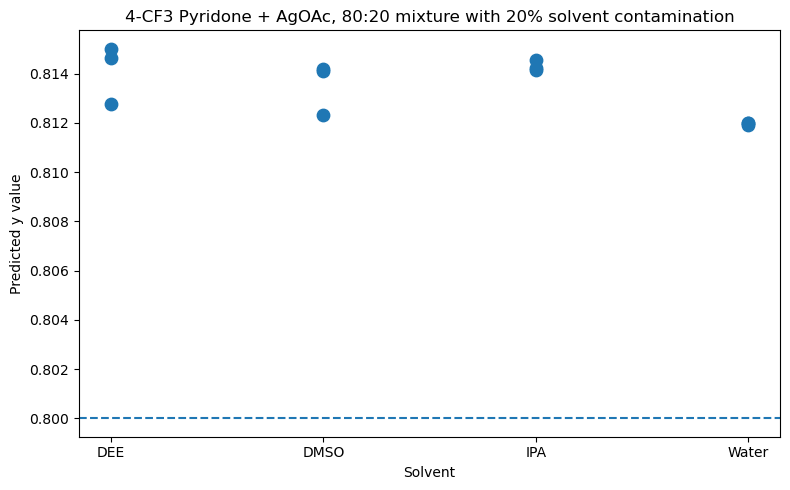

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # 4-CF3 + AgOAc
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

# SETTINGS
fractions      = np.linspace(0.0, 1.2, 121)  # full calibration curve
alphas = np.arange(0.05, 0.25, 0.05)  # up to 20%                     # 20% solvent contamination
n_components   = 5
true_fraction_alpha = 0.8                      # test mixture fraction Alpha
true_fraction_ag    = 0.2                      # test mixture fraction AgOAc

# FUNCTIONS
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol_filter_spec(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

def synthesize_spectrum(alpha_spec, ag_spec, fraction_alpha):
    return fraction_alpha * alpha_spec + (1 - fraction_alpha) * ag_spec

# LOAD PURE
alpha_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

ag_files = [
    'YH_2025_010_AgOAC_A.CSV',
    'YH_2025_010_AgOAC_B.CSV',
    'YH_2025_010_AgOAC_C.CSV'
]

alpha_specs = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in alpha_files]
ag_specs    = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in ag_files]

#LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = np.interp(np.linspace(0, 1, len(alpha_specs[0])), np.linspace(0, 1, len(s)), s)
    s = normalize(savgol_filter_spec(s))
    solvents.append(s)

# SYNTHETIC CALIBRATION
X_cal, y_cal = [], []

rng = np.random.default_rng(42)
for solvent in solvents:
    for frac in fractions:
        for alpha_val in alphas:
            # randomly pick alpha and AgOAc spectra
            alpha_spec = alpha_specs[rng.integers(len(alpha_specs))]
            ag_spec    = ag_specs[rng.integers(len(ag_specs))]

            # make mixture + solvent contamination
            mix_spec = synthesize_spectrum(alpha_spec, ag_spec, frac)
            synthetic_spec = (mix_spec + alpha_val * solvent) / (1 + alpha_val)

            X_cal.append(synthetic_spec)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
print(f"Synthetic calibration set size: {X_cal.shape[0]} samples × {X_cal.shape[1]} features")

# SCALE & MODEL
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# TEST
test_files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith('.csv'))

predictions, maes = [], []

for f in test_files:
    # choose random alpha and AgOAc for the test mixture
    alpha_spec = alpha_specs[rng.integers(len(alpha_specs))]
    ag_spec    = ag_specs[rng.integers(len(ag_specs))]

    # make 80:20 mixture
    s_test = synthesize_spectrum(alpha_spec, ag_spec, true_fraction_alpha)

    # add 20% solvent contamination (choose corresponding solvent from file name)
    solvent_idx = None
    for i, sol in enumerate(['DEE','DMSO','IPA','Water']):
        if sol in f:
            solvent_idx = i
            break
    if solvent_idx is not None:
        s_test = (s_test + alphas[0] * solvents[solvent_idx]) / (1 + alphas[0])

    s_scaled = scaler.transform(s_test.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])
    mae = mean_absolute_error([true_fraction_alpha], [y_pred])

    predictions.append((f, y_pred))
    maes.append(mae)
    print(f"{f}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

# PLOT
labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_fraction_alpha, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Pyridone + AgOAc, 80:20 mixture with 20% solvent contamination')
plt.tight_layout()
plt.show()

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'

# SETTINGS
fractions = np.linspace(0.0, 1.2, 121)
alphas    = np.arange(0.05, 0.25, 0.05)   # 20% contamination range
n_components = 5
n_splits = 5

# FUNCTIONS
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol_filter_spec(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

def synthesize_spectrum(alpha_spec, ag_spec, fraction_alpha):
    return fraction_alpha * alpha_spec + (1 - fraction_alpha) * ag_spec

# LOAD PURE SPECTRA
alpha_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

ag_files = [
    'YH_2025_010_AgOAC_A.CSV',
    'YH_2025_010_AgOAC_B.CSV',
    'YH_2025_010_AgOAC_C.CSV'
]

alpha_specs = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in alpha_files]
ag_specs    = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in ag_files]

n_features = min(len(s) for s in alpha_specs)
alpha_specs = [s[:n_features] for s in alpha_specs]
ag_specs    = [s[:n_features] for s in ag_specs]

print(f"Loaded Alpha + AgOAc spectra ({n_features} features)")

# LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = np.interp(np.linspace(0,1,n_features), np.linspace(0,1,len(s)), s)
    s = normalize(savgol_filter_spec(s))
    solvents.append(s)

print(f"Loaded {len(solvents)} solvent spectra")

# SYNTHETIC DATA + GROUPS
X_cal, y_cal, groups = [], [], []

rng = np.random.default_rng(42)
group_id = 0

for solvent_idx, solvent in enumerate(solvents):
    for i_alpha, alpha_base in enumerate(alpha_specs):
        for i_ag, ag_base in enumerate(ag_specs):

            # ONE group = same base spectra + solvent
            for frac in fractions:
                for alpha_val in alphas:

                    mix_spec = synthesize_spectrum(alpha_base, ag_base, frac)
                    synthetic = (mix_spec + alpha_val * solvent) / (1 + alpha_val)

                    X_cal.append(synthetic)
                    y_cal.append(frac)
                    groups.append(group_id)

            group_id += 1  # increment AFTER full family

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
groups = np.array(groups)

print(f"Synthetic dataset: {X_cal.shape[0]} samples")
print(f"Total groups: {len(np.unique(groups))}")

#  GROUP K-FOLD CV 
gkf = GroupKFold(n_splits=n_splits)

mae_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_cal, y_cal, groups)):
    print(f"\nFold {fold+1}")

    X_train, X_test = X_cal[train_idx], X_cal[test_idx]
    y_train, y_test = y_cal[train_idx], y_cal[test_idx]

    # IMPORTANT: fit scaler ONLY on training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train_scaled, y_train)

    y_pred = pls.predict(X_test_scaled).ravel()
    mae = mean_absolute_error(y_test, y_pred)

    mae_scores.append(mae)
    print(f"MAE: {mae:.4f}")

print("\n========================")
print(f"CV MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print("========================")

Loaded Alpha + AgOAc spectra (7468 features)
Loaded 4 solvent spectra
Synthetic dataset: 17424 samples
Total groups: 36

Fold 1
MAE: 0.0134

Fold 2
MAE: 0.0134

Fold 3
MAE: 0.0134

Fold 4
MAE: 0.0134

Fold 5
MAE: 0.0134

CV MAE: 0.0134 ± 0.0000


Loaded CF3 pure spectra (7468 features)
Loaded 4 solvent spectra
Synthetic calibration size: 2904
YH_2025_012_DEE_A.CSV: y = 0.7638, MAE = 0.0362
YH_2025_012_DEE_B.CSV: y = 0.7662, MAE = 0.0338
YH_2025_012_DEE_C.CSV: y = 0.7678, MAE = 0.0322
YH_2025_012_DMSO_A.CSV: y = 0.7634, MAE = 0.0366
YH_2025_012_DMSO_B.CSV: y = 0.7589, MAE = 0.0411
YH_2025_012_DMSO_C.CSV: y = 0.7706, MAE = 0.0294
YH_2025_012_IPA_A(real).CSV: y = 0.7789, MAE = 0.0211
YH_2025_012_IPA_B(real).CSV: y = 0.7675, MAE = 0.0325
YH_2025_012_IPA_C(real).CSV: y = 0.7578, MAE = 0.0422
YH_2025_012_Water_A.CSV: y = 0.7317, MAE = 0.0683
YH_2025_012_Water_B.CSV: y = 0.7250, MAE = 0.0750
YH_2025_012_Water_C.CSV: y = 0.7439, MAE = 0.0561

Average MAE: 0.0420


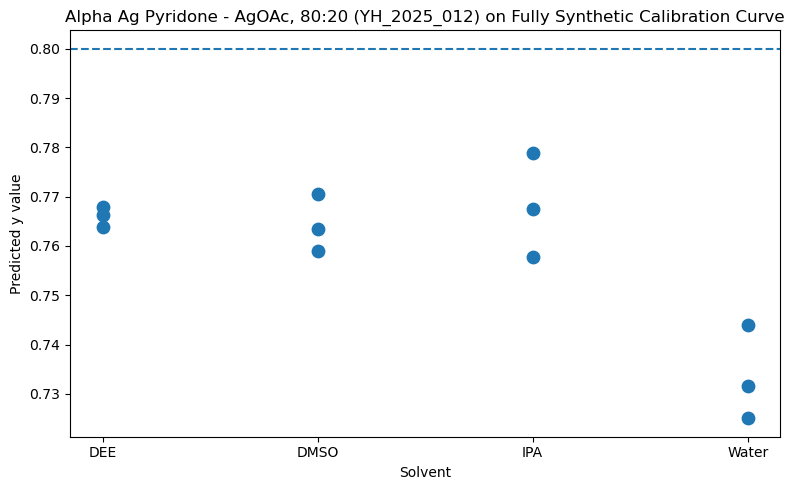

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

fractions     = np.linspace(0.4, 1.2, 121)   
alphas        = np.linspace(0.06, 0.28, 6)   
n_components  = 5               
true_y        = 0.8               

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def average_replicates(files):
    specs = [load_spectrum(f) for f in files]
    min_len = min(len(s) for s in specs)
    specs = [s[:min_len] for s in specs]
    return np.mean(specs, axis=0)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)


cf3_files = [
    'YH_2025_010_ALPHA_A.CSV',
    'YH_2025_010_ALPHA_B.CSV',
    'YH_2025_010_ALPHA_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]
pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )
    s = normalize(s)
    s = savgol(s)
    solvents.append(s)

solvents = np.array(solvents)
print(f"Loaded {len(solvents)} solvent spectra")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:
            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)
            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('Alpha Ag Pyridone - AgOAc, 80:20 (YH_2025_012) on Fully Synthetic Calibration Curve')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})

Synthetic calibration set size: 3213 samples × 7468 features
YH_2025_012_DEE_A.CSV: y=0.8261, MAE=0.0261
YH_2025_012_DEE_B.CSV: y=0.9001, MAE=0.1001
YH_2025_012_DEE_C.CSV: y=0.8261, MAE=0.0261
YH_2025_012_DMSO_A.CSV: y=0.8796, MAE=0.0796
YH_2025_012_DMSO_B.CSV: y=0.8261, MAE=0.0261
YH_2025_012_DMSO_C.CSV: y=0.8796, MAE=0.0796
YH_2025_012_IPA_A(real).CSV: y=0.8871, MAE=0.0871
YH_2025_012_IPA_B(real).CSV: y=0.8796, MAE=0.0796
YH_2025_012_IPA_C(real).CSV: y=0.8992, MAE=0.0992
YH_2025_012_Water_A.CSV: y=0.8261, MAE=0.0261
YH_2025_012_Water_B.CSV: y=0.8261, MAE=0.0261
YH_2025_012_Water_C.CSV: y=0.8871, MAE=0.0871

Average MAE: 0.0619


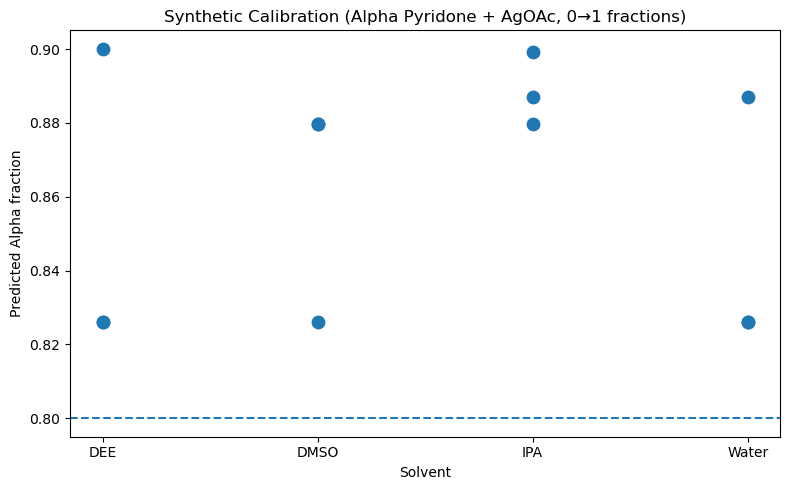

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# PATHS
alpha_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # Alpha Pyridone spectra (triplicates)
agoac_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # AgOAc spectra (triplicates)
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir  = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

#SETTINGS
n_components = 5
true_fraction_alpha = 0.8  # test mixture 80:20
alpha_solvent_values = np.arange(0.1, 0.5, 0.1)  # 10-40% solvent contamination

# FILES
alpha_files = ['YH_2025_010_ALPHA_A.CSV',
               'YH_2025_010_ALPHA_B.CSV',
               'YH_2025_010_ALPHA_C.CSV']

agoac_files = ['YH_2025_010_AgOAC_A.CSV',
               'YH_2025_010_AgOAC_B.CSV',
               'YH_2025_010_AgOAC_C.CSV']

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

# FUNCTIONS
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:,1].values

def synthesize_spectrum(alpha_s, ag_s, fraction):
    """Linear combination of Alpha Pyridone and AgOAc"""
    return fraction * alpha_s + (1 - fraction) * ag_s

#LOAD PURE SPECTRA 
alpha_specs = np.array([load_spectrum(os.path.join(alpha_dir,f)) for f in alpha_files])
agoac_specs = np.array([load_spectrum(os.path.join(agoac_dir,f)) for f in agoac_files])

n_features = min(alpha_specs.shape[1], agoac_specs.shape[1])
alpha_specs = alpha_specs[:, :n_features]
agoac_specs = agoac_specs[:, :n_features]

# LOAD SOLVENTS
solvents = {}
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir,f))[:n_features]
    solvents[f.split('.')[0]] = s

#SYNTHETIC CALIBRATION
fractions = np.linspace(0,1,21)  # full calibration
X_cal, y_cal = [], []

for alpha_s in alpha_specs:
    for ag_s in agoac_specs:
        for frac in fractions:
            base_spectrum = synthesize_spectrum(alpha_s, ag_s, frac)
            X_cal.append(base_spectrum)
            y_cal.append(frac)

# Add solvent contamination to calibration
X_aug, y_aug = [], []
for spec, y_val in zip(X_cal, y_cal):
    X_aug.append(spec)
    y_aug.append(y_val)
    for solvent_name, solvent_spec in solvents.items():
        for alpha_sol in alpha_solvent_values:
            contaminated = (spec + alpha_sol * solvent_spec)/(1+alpha_sol)
            X_aug.append(contaminated)
            y_aug.append(y_val)

X_cal = np.array(X_aug)
y_cal = np.array(y_aug)
print(f"Synthetic calibration set size: {X_cal.shape[0]} samples × {X_cal.shape[1]} features")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

# MODEL
pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# TEST
test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])

predictions, maes = [], []

for f in test_files:
    # Choose random alpha and AgOAc spectra for the test mixture
    s_alpha = alpha_specs[np.random.randint(len(alpha_specs))]
    s_ag    = agoac_specs[np.random.randint(len(agoac_specs))]

    # Make 80:20 mixture for testing
    s_test = synthesize_spectrum(s_alpha, s_ag, true_fraction_alpha)

    s_scaled = scaler.transform(s_test.reshape(1,-1))
    y_pred = float(pls.predict(s_scaled)[0])
    mae = mean_absolute_error([true_fraction_alpha],[y_pred])

    predictions.append((f, y_pred))
    maes.append(mae)

    print(f"{f}: y={y_pred:.4f}, MAE={mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

#pLOT
solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions, y_plot = [], []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_fraction_alpha, linestyle='--')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted Alpha fraction')
plt.title('Synthetic Calibration (Alpha Pyridone + AgOAc, 0→1 fractions)')
plt.tight_layout()
plt.show()

In [3]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold

#PATHS
alpha_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
agoac_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'

#SETTINGS
n_components = 5
alpha_solvent_values = np.arange(0.1, 0.5, 0.1)
fractions = np.linspace(0,1,21)
n_splits = 5

# FUNCTIONS
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:,1].values

def synthesize_spectrum(alpha_s, ag_s, fraction):
    return fraction * alpha_s + (1 - fraction) * ag_s

# LOAD PURE 
alpha_files = [
    'YH_2025_010_ALPHA_A.CSV',
    'YH_2025_010_ALPHA_B.CSV',
    'YH_2025_010_ALPHA_C.CSV'
]

agoac_files = [
    'YH_2025_010_AgOAC_A.CSV',
    'YH_2025_010_AgOAC_B.CSV',
    'YH_2025_010_AgOAC_C.CSV'
]

alpha_specs = np.array([load_spectrum(os.path.join(alpha_dir,f)) for f in alpha_files])
agoac_specs = np.array([load_spectrum(os.path.join(agoac_dir,f)) for f in agoac_files])

n_features = min(alpha_specs.shape[1], agoac_specs.shape[1])
alpha_specs = alpha_specs[:, :n_features]
agoac_specs = agoac_specs[:, :n_features]

# LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir,f))[:n_features]
    solvents.append(s)

# SYNTHETIC + GROUPS
X_cal, y_cal, groups = [], [], []

group_id = 0

for i_alpha, alpha_s in enumerate(alpha_specs):
    for i_ag, ag_s in enumerate(agoac_specs):
        for frac in fractions:

            base_spec = synthesize_spectrum(alpha_s, ag_s, frac)

            # group = same base spectrum
            # (all solvent augmentations belong here)

            # original (no solvent)
            X_cal.append(base_spec)
            y_cal.append(frac)
            groups.append(group_id)

            # solvent augmented
            for solvent in solvents:
                for alpha_sol in alpha_solvent_values:
                    contaminated = (base_spec + alpha_sol * solvent)/(1+alpha_sol)

                    X_cal.append(contaminated)
                    y_cal.append(frac)
                    groups.append(group_id)

            group_id += 1

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
groups = np.array(groups)

print(f"Synthetic dataset: {X_cal.shape[0]} samples")
print(f"Total groups: {len(np.unique(groups))}")

#  GROUP K-FOLD
gkf = GroupKFold(n_splits=n_splits)

mae_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_cal, y_cal, groups)):
    print(f"\nFold {fold+1}")

    X_train, X_test = X_cal[train_idx], X_cal[test_idx]
    y_train, y_test = y_cal[train_idx], y_cal[test_idx]

    # scale properly (no leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train_scaled, y_train)

    y_pred = pls.predict(X_test_scaled).ravel()
    mae = mean_absolute_error(y_test, y_pred)

    mae_scores.append(mae)
    print(f"MAE: {mae:.4f}")

print("\n========================")
print(f"CV MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print("========================")

Synthetic dataset: 3213 samples
Total groups: 189

Fold 1
MAE: 0.0364

Fold 2
MAE: 0.0354

Fold 3
MAE: 0.0355

Fold 4
MAE: 0.0361

Fold 5
MAE: 0.0335

CV MAE: 0.0354 ± 0.0010


Loaded CF3 pure spectra (7468 features)
Loaded 9 solvent spectra (HFIP/DCE/Toluene, A–C)
Synthetic calibration size: 6534
YH_2025_009_DEE_A.CSV: y = 0.8213, MAE = 0.0213
YH_2025_009_DEE_B.CSV: y = 0.8207, MAE = 0.0207
YH_2025_009_DEE_C.CSV: y = 0.8332, MAE = 0.0332
YH_2025_009_DMSO_A.CSV: y = 0.8122, MAE = 0.0122
YH_2025_009_DMSO_B.CSV: y = 0.8120, MAE = 0.0120
YH_2025_009_DMSO_C.CSV: y = 0.8074, MAE = 0.0074
YH_2025_009_IPA_A.CSV: y = 0.8221, MAE = 0.0221
YH_2025_009_IPA_B.CSV: y = 0.8065, MAE = 0.0065
YH_2025_009_IPA_C.CSV: y = 0.8141, MAE = 0.0141
YH_2025_009_Water_A.CSV: y = 0.8009, MAE = 0.0009
YH_2025_009_Water_B.CSV: y = 0.8043, MAE = 0.0043
YH_2025_009_Water_C.CSV: y = 0.8611, MAE = 0.0611

Average MAE: 0.0180


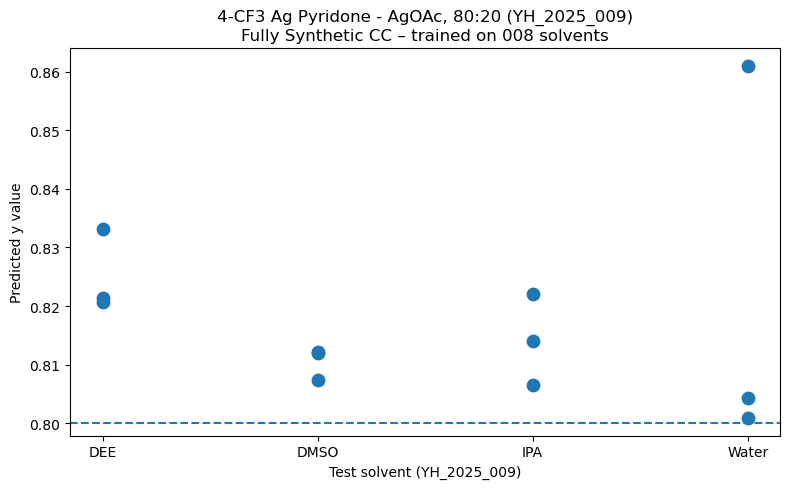

In [5]:
#Optimization Testing
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

fractions     = np.linspace(0.4, 1.2, 121)
alphas        = np.linspace(0.06, 0.28, 6)
n_components  = 5
true_y        = 0.8

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)


cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]
pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")


solvent_files = [
    'YH_2025_008_HFIP_A.csv',
    'YH_2025_008_HFIP_B.csv',
    'YH_2025_008_HFIP_C.csv',

    'YH_2025_008_DCE_A.csv',
    'YH_2025_008_DCE_B.csv',
    'YH_2025_008_DCE_C.csv',

    'YH_2025_008_Toluene_A.csv',
    'YH_2025_008_Toluene_B.csv',
    'YH_2025_008_Toluene_C.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))

    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )

    s = normalize(s)
    s = savgol(s)

    solvents.append(s)

solvents = np.array(solvents)

print(f"Loaded {len(solvents)} solvent spectra (HFIP/DCE/Toluene, A–C)")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:

            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)

            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")


scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)


test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:

    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = []
y = []

for fname, ypred in predictions:
    # YH_2025_009_DEE_A.CSV  ->  DEE
    solvent = fname.split('_')[3]
    labels.append(solvent)
    y.append(ypred)

unique_labels = list(dict.fromkeys(labels))
x_map = {s: i for i, s in enumerate(unique_labels)}
x = [x_map[s] for s in labels]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(unique_labels)), unique_labels)
plt.xlabel('Test solvent (YH_2025_009)')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009)\nFully Synthetic CC – trained on 008 solvents')
plt.tight_layout()
plt.show()

Loaded CF3 pure spectra (7468 features)
Loaded 9 solvent spectra
Synthetic calibration size: 6534
YH_2025_009_DEE_A.CSV: y = 0.8213, MAE = 0.0213
YH_2025_009_DEE_B.CSV: y = 0.8207, MAE = 0.0207
YH_2025_009_DEE_C.CSV: y = 0.8332, MAE = 0.0332
YH_2025_009_DMSO_A.CSV: y = 0.8122, MAE = 0.0122
YH_2025_009_DMSO_B.CSV: y = 0.8120, MAE = 0.0120
YH_2025_009_DMSO_C.CSV: y = 0.8074, MAE = 0.0074
YH_2025_009_IPA_A.CSV: y = 0.8221, MAE = 0.0221
YH_2025_009_IPA_B.CSV: y = 0.8065, MAE = 0.0065
YH_2025_009_IPA_C.CSV: y = 0.8141, MAE = 0.0141
YH_2025_009_Water_A.CSV: y = 0.8009, MAE = 0.0009
YH_2025_009_Water_B.CSV: y = 0.8043, MAE = 0.0043
YH_2025_009_Water_C.CSV: y = 0.8611, MAE = 0.0611

Average MAE: 0.0180


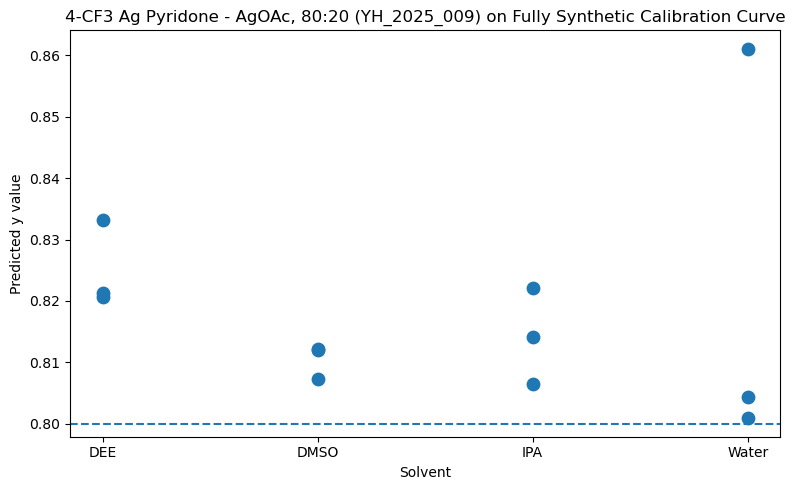

In [1]:
#Optimization Testing
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

fractions     = np.linspace(0.4, 1.2, 121)   
alphas        = np.linspace(0.06, 0.28, 6)   
n_components  = 5            
true_y        = 0.8               

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def average_replicates(files):
    specs = [load_spectrum(f) for f in files]
    min_len = min(len(s) for s in specs)
    specs = [s[:min_len] for s in specs]
    return np.mean(specs, axis=0)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)


cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]
pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")

solvent_files = [
    'YH_2025_008_HFIP_A.csv',
    'YH_2025_008_HFIP_B.csv',
    'YH_2025_008_HFIP_C.csv',

    'YH_2025_008_DCE_A.csv',
    'YH_2025_008_DCE_B.csv',
    'YH_2025_008_DCE_C.csv',

    'YH_2025_008_Toluene_A.csv',
    'YH_2025_008_Toluene_B.csv',
    'YH_2025_008_Toluene_C.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )
    s = normalize(s)
    s = savgol(s)
    solvents.append(s)

solvents = np.array(solvents)
print(f"Loaded {len(solvents)} solvent spectra")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:
            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)
            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Fully Synthetic Calibration Curve')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})